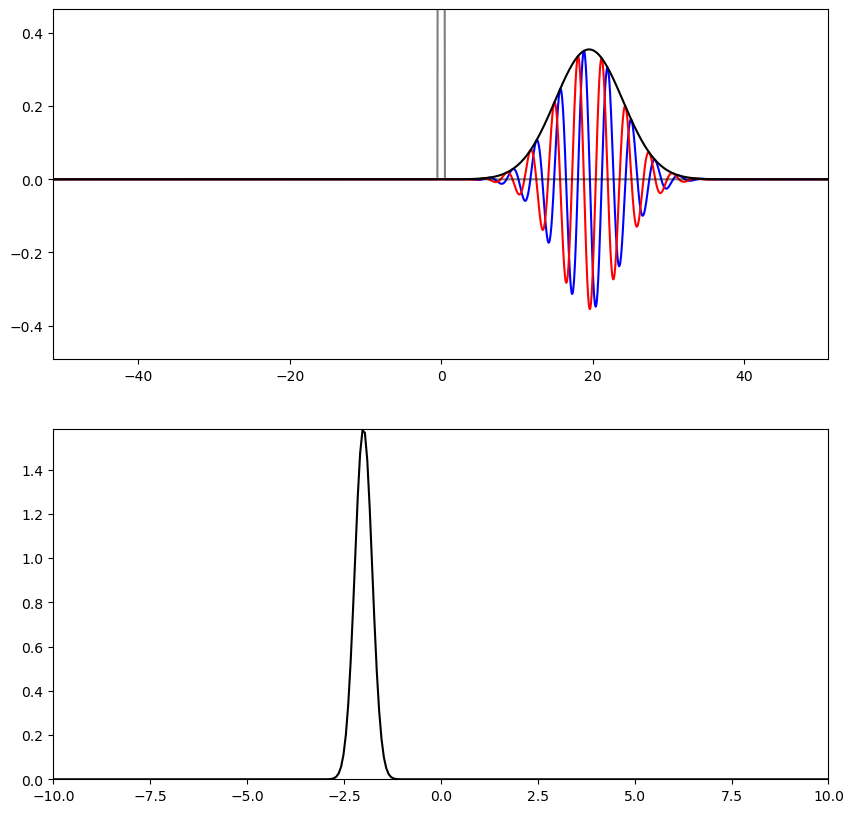

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


def split_step_schrodinger(psi_0, dx, dt, V, N, x_0 = 0., k_0 = None, m = 1.0, non_linear = False):

    len_x = psi_0.shape[0]

    x = x_0 + dx*np.arange(len_x)

    dk_x = (2*np.pi)/(len_x*dx)
    if k_0 == None:
        k_0 = -np.pi/dx
    k_x = k_0+dk_x*np.arange(len_x)

    psi_x = np.zeros((len_x,N), dtype = np.complex128)
    psi_k = np.zeros((len_x,N), dtype = np.complex128)
    psi_mod_x = np.zeros((len_x), dtype = np.complex128)
    psi_mod_k = np.zeros((len_x), dtype = np.complex128)
    psi_x[:,0] = psi_0

    if not non_linear:
        V_n = V(x)
    else:
        V_n = V(x,psi_0)

    def _compute_psi_mod(j):
        return (dx/np.sqrt(2*np.pi))*psi_x[:,j]*np.exp(-1.0j*k_x[0]*x)

    def _compute_psi(j):
        psi_x[:,j] = (np.sqrt(2*np.pi)/dx)*psi_mod_x*np.exp(1.0j*k_x[0]*x)
        psi_k[:,j] = psi_mod_k*np.exp(-1.0j*x[0]*dk_x*np.arange(len_x))

    def _x_half_step(j,ft = True):
        if ft == True:
            psi_mod_x[:] = np.fft.ifft(psi_mod_k[:])
        if non_linear:
            V_n[:] = V(x,psi_x[:,j])
        psi_mod_x[:] = psi_mod_x[:]*np.exp(-1.0j*(dt/2.)*V_n)   

    def _k_full_step():
        psi_mod_k[:] = np.fft.fft(psi_mod_x[:])
        psi_mod_k[:] = psi_mod_k[:]*np.exp(-1.0j*k_x**2*dt/(2.*m))      

    def _main_loop():
        psi_mod_x[:] = _compute_psi_mod(0)

        for i in range(N-1):
            _x_half_step(i,ft = False)
            _k_full_step()
            _x_half_step(i)
            _compute_psi(i+1)

    _main_loop()

    return psi_x,psi_k,k_x
def oneD_gaussian(x,mean,std,k0):
    return np.exp(-((x-mean)**2)/(4*std**2)+ 1j*x*k0)/(2*np.pi*std**2)**0.25

def V(x):
    V_x = np.zeros_like(x)
    V_x[np.where(abs(x) < 0.5)] = 1.5
    return V_x
N_x = 2**11
dx = 0.05
x = dx * (np.arange(N_x) - 0.5 * N_x)

dt = 0.01
N_t = 2000

p0 = 2.0
d = np.sqrt(N_t*dt/2.)

psi_0 = oneD_gaussian(x,x.max()-10.*d, d, -p0)

psi_x,psi_k,k = split_step_schrodinger(psi_0, dx, dt, V, N_t, x_0 = x[0])
from matplotlib.animation import FuncAnimation

real_psi = np.real(psi_x)
imag_psi = np.imag(psi_x)
absl_psi = np.absolute(psi_x)
abs_psik = np.absolute(psi_k)

fig = plt.figure(figsize = (10,10))
ax1 = plt.subplot(211)
line1_R = ax1.plot(x,real_psi[:,0],'b')[0]
line1_I = ax1.plot(x,imag_psi[:,0],'r')[0]
line1_A = ax1.plot(x,absl_psi[:,0],'k')[0]
line_V = ax1.plot(x,0.5*V(x),'k',alpha=0.5)[0]
ax1.set_ylim((real_psi.min(),real_psi.max()))
ax1.set_xlim((x.min(),x.max()))

ax2 = plt.subplot(212)
line2 = ax2.plot(k,abs_psik[:,1],'k')[0]
ax2.set_ylim((abs_psik.min(),abs_psik.max()))
ax2.set_xlim((-10,10))

def nextframe(arg):
    line1_R.set_data(x,real_psi[:,10*arg])
    line1_I.set_data(x,imag_psi[:,10*arg])
    line1_A.set_data(x,absl_psi[:,10*arg])
    line2.set_data(k,abs_psik[:,10*arg])
    
animate = FuncAnimation(fig, nextframe, frames = int(N_t/10), interval = 50, repeat = False)
plt.show()

* Find the frequency components of a signal buried in noise and find the amplitudes of the peak frequencies by using Fourier transform.

* Specify the parameters of a signal with a sampling frequency of 2 kHz and a signal duration of 5 seconds.

* Form a signal containing a DC offset of amplitude 0.8, a 50 Hz sinusoid of amplitude 0.7, and a 120 Hz sinusoid of amplitude 1.
* Corrupt the signal with zero-mean random noise with a variance of 4.
* Plot the noisy signal in the time domain. The frequency components are not visually apparent in the plot.

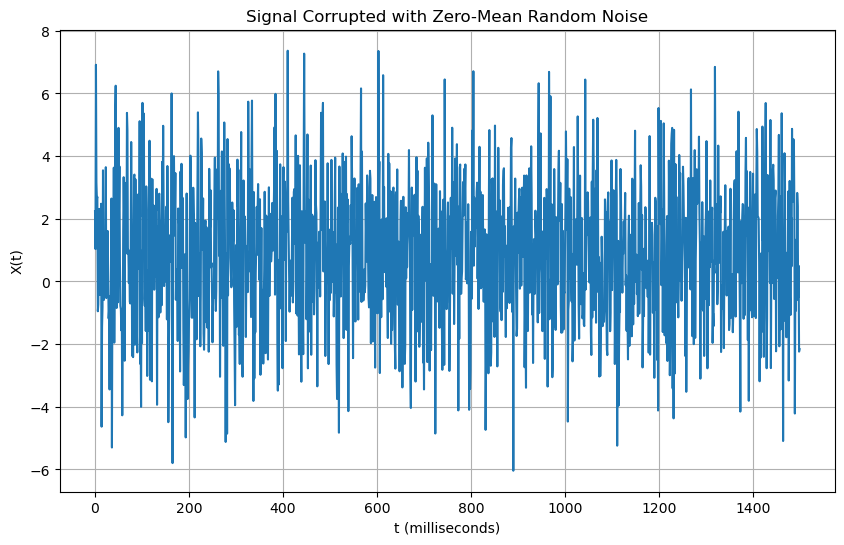

In [9]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000                          
T = 1 / Fs                           
L = 1500                             
t = np.arange(0, L) * T               

S = 0.8 + 0.7 * np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)


X = S + 2 * np.random.randn(len(t))

plt.figure(figsize=(10, 6))
plt.plot(1000 * t, X)                 
plt.title("Signal Corrupted with Zero-Mean Random Noise")
plt.xlabel("t (milliseconds)")
plt.ylabel("X(t)")
plt.grid(True)                       
plt.show()


**Compute the Fourier transform of the signal**

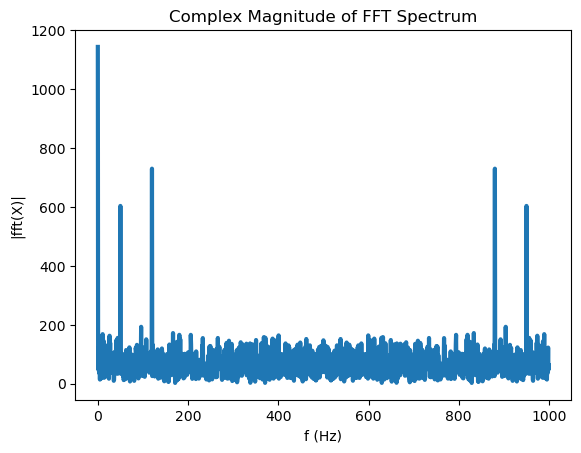

In [10]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000 
L = 1500  

t = np.arange(L) / Fs
S = 0.8 + 0.7 * np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)  
X = S + 2 * np.random.randn(L)

Y = np.fft.fft(X)

f = Fs / L * np.arange(L)
plt.plot(f, np.abs(Y), linewidth=3)
plt.title("Complex Magnitude of FFT Spectrum")
plt.xlabel("f (Hz)")
plt.ylabel("|fft(X)|")
plt.show()


The plot shows five frequency peaks including the peak at 0 Hz for the DC offset. In this example, the signal is expected to have three frequency peaks at 0 Hz, 50 Hz, and 120 Hz. Here, the second half of the plot is the mirror reflection of the first half without including the peak at 0 Hz. The reason is that the discrete Fourier transform of a time-domain signal has a periodic nature, where the first half of its spectrum is in positive frequencies and the second half is in negative frequencies, with the first element reserved for the zero frequency.

For real signals, the FFT spectrum is a two-sided spectrum, where the spectrum in the positive frequencies is the complex conjugate of the spectrum in the negative frequencies. To show the fft spectrum in the positive and negative frequencies, you can use fftshift. For an even length of L, the frequency domain starts from the negative of the Nyquist frequency $$-F_s/2$$ up to $$F_s/2 -F_s/L$$ with a spacing or frequency resolution of $$F_s/L$$.

This is an initial algorithm I did for finding specific function of frequency given a signal was surrounded with noise. this works in vibration, oscillation, and quantum infortmation in discretion.  "Quantum Fourier Transform (QFT)" - essentially a way to efficiently analyze frequencies of a quantum state, similar to how the classical FFT does for digital signals, but leveraging the unique properties of quantum mechanics to achieve potential speedups in certain applications. the two can be combine when probabilty is difficult.

This I did for fun now onto project parameters.

__Physical System and FFT Application__
System Description:
Imagine we are modeling a sensor system measuring the vibration of a machine part, such as a rotating motor. The signal from the sensor is corrupted by various types of noise (e.g., electrical noise, mechanical vibrations from other parts of the machine, etc.).

We can use FFT to:

Identify the frequencies of the motor's vibrations.
Extract and isolate the dominant frequency components (e.g., the rotational speed of the motor).
Remove noise by filtering out unwanted frequencies.
Data Used:
For simplicity, we'll generate a synthetic signal that combines a known sinusoidal frequency (representing the motor's vibration) and noise. This is a simplified version of real-world sensor data.

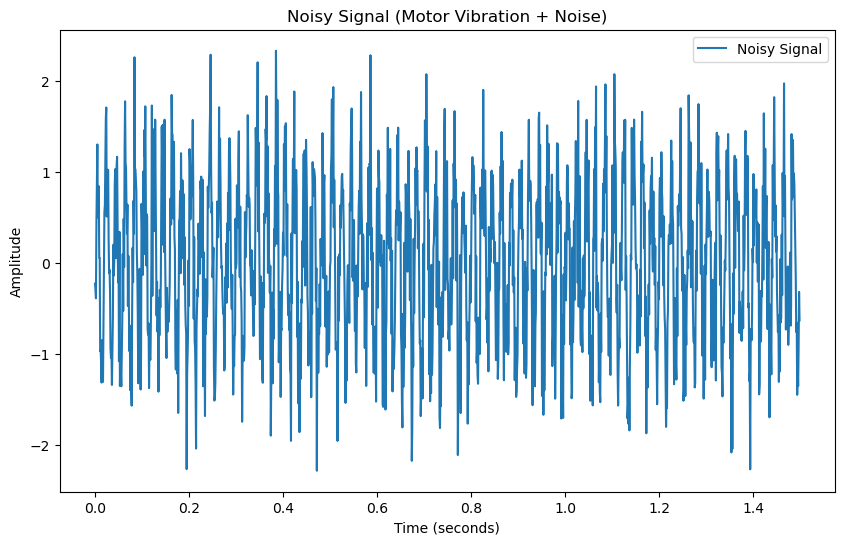

In [11]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000  
T = 1/Fs 
L = 1500  
t = np.arange(L) * T 

motor_freq = 50 
signal = np.sin(2 * np.pi * motor_freq * t) 

noise = 0.5 * np.random.randn(L)
X = signal + noise 

plt.figure(figsize=(10, 6))
plt.plot(t, X, label="Noisy Signal")
plt.title("Noisy Signal (Motor Vibration + Noise)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


_Assumptions and Limitations:_

__Assumptions:__

The motor vibration frequency is constant.
The noise is Gaussian and white (i.e., it has a flat frequency spectrum).
We are sampling at a sufficiently high frequency to capture the motor vibration signal.

__Limitations:__

The signal may have more complex characteristics in real-life data.
The noise may not always be Gaussian or white.
We are assuming a simple sinusoidal model for the motor vibration, which might not hold in all scenarios.

__Numerical Investigation Using FFT__
Perform FFT on the Noisy Signal:
The goal is to transform the time-domain signal into the frequency domain to analyze its frequency components. The FFT will help identify the dominant frequencies in the signal, and we can then clean up the signal by removing unwanted frequencies.

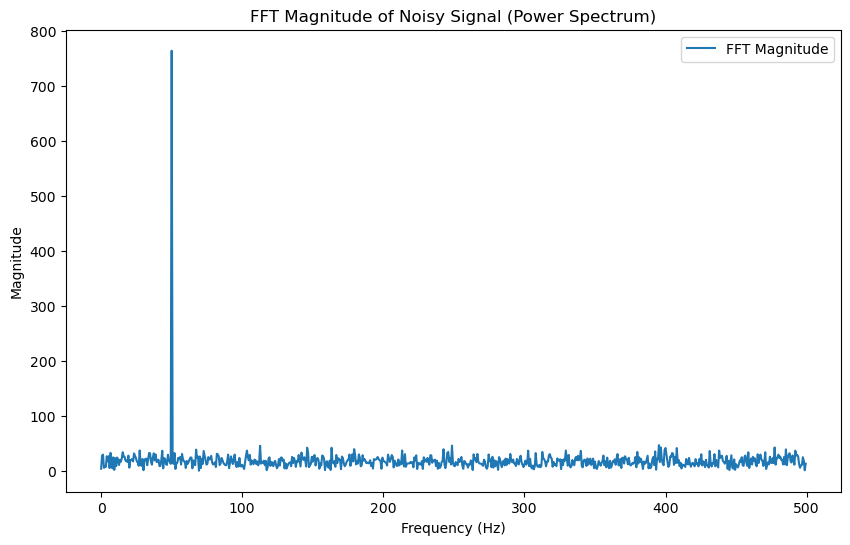

In [12]:
Y = np.fft.fft(X)

f = np.fft.fftfreq(L, T)

half_L = L // 2
f_pos = f[:half_L]
Y_pos = Y[:half_L]

plt.figure(figsize=(10, 6))
plt.plot(f_pos, np.abs(Y_pos), label="FFT Magnitude")
plt.title("FFT Magnitude of Noisy Signal (Power Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()


__Analyzing the Power Spectrum:__

In the FFT plot, the x-axis represents frequency, and the y-axis represents the magnitude of each frequency component. We should observe a prominent peak around the motor's frequency (50 Hz), but there will also be noise present at other frequencies.

__Signal Cleaning Using Frequency Filtering__

To clean the signal, we can filter out the noise by setting the magnitudes of the unwanted frequencies to zero. This can be done by creating a filter that allows only frequencies near the motor's vibration frequency to pass through.

__Frequency Filtering:__

We can apply a band-pass filter around the motor's frequency (50 Hz) to preserve the signal of interest and remove high-frequency noise.

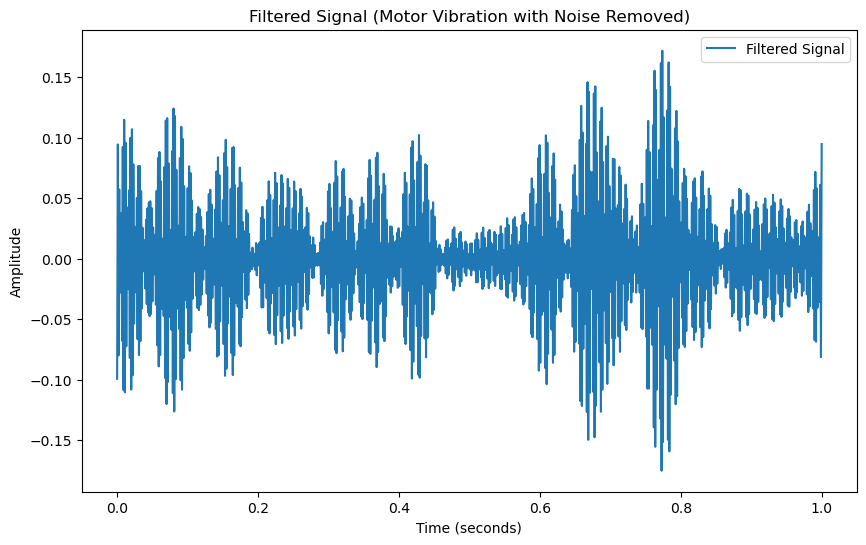

In [19]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000 
t = np.linspace(0, 1, fs)

f_motor = 50  
signal_motor = np.sin(2 * np.pi * f_motor * t)
noise = np.random.normal(0, 0.5, size=t.shape)
signal = signal_motor + noise

Y = np.fft.fft(signal)
f_pos = np.fft.fftfreq(len(t), 1/fs)
f_pos = np.fft.fftshift(f_pos)  

filter_low = 40  
filter_high = 60 

mask = (f_pos >= filter_low) & (f_pos <= filter_high)

Y_filtered = Y.copy()
Y_filtered[~mask] = 0 

X_filtered = np.fft.ifft(Y_filtered)

plt.figure(figsize=(10, 6))
plt.plot(t, np.real(X_filtered), label="Filtered Signal")
plt.title("Filtered Signal (Motor Vibration with Noise Removed)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()


 __Conclusion and Observations__

The FFT helped us identify the dominant frequency in the noisy signal (around 50 Hz).
By applying a band-pass filter, we were able to remove unwanted frequencies and reconstruct a cleaner version of the original motor vibration signal.
This approach demonstrates how FFT can be used for signal analysis, noise filtering, and frequency extraction.

__Documentation and Explanation__
The steps performed are:

Generated a synthetic signal with known characteristics (motor vibration + noise).
Applied FFT to transform the signal into the frequency domain.
Analyzed the power spectrum to identify key frequency components.
Implemented a frequency filtering technique to clean the signal.
Reconstructed the filtered signal and compared it with the noisy original.
By using these steps, you can use FFT to analyze and clean signals in many real-world applications, such as vibration analysis, audio signal processing, and more.


Now same problem second example. This application of noise is cleared up using the algorithm from befor the project.

**Physical System and FFT Application
System Description:**
In this case, we model the variation in heart rate over time, which is often measured in ECG (Electrocardiogram) signals or through devices that track the heartbeats of a subject. The signal we use will have noise (e.g., due to measurement inaccuracies or external interference), and our goal is to clean the signal using FFT and analyze its frequency components to understand the heart's activity better.

The key frequencies in the HRV signal are typically:

**Low Frequency (LF):** Associated with sympathetic nervous activity.

**High Frequency (HF):** Associated with parasympathetic nervous activity.
Very Low Frequency (VLF): Associated with long-term rhythms like thermoregulation.
We can use FFT to:

Extract the frequency components of HRV.
Clean the signal and remove high-frequency noise.
Identify the LF and HF components and analyze the balance between them

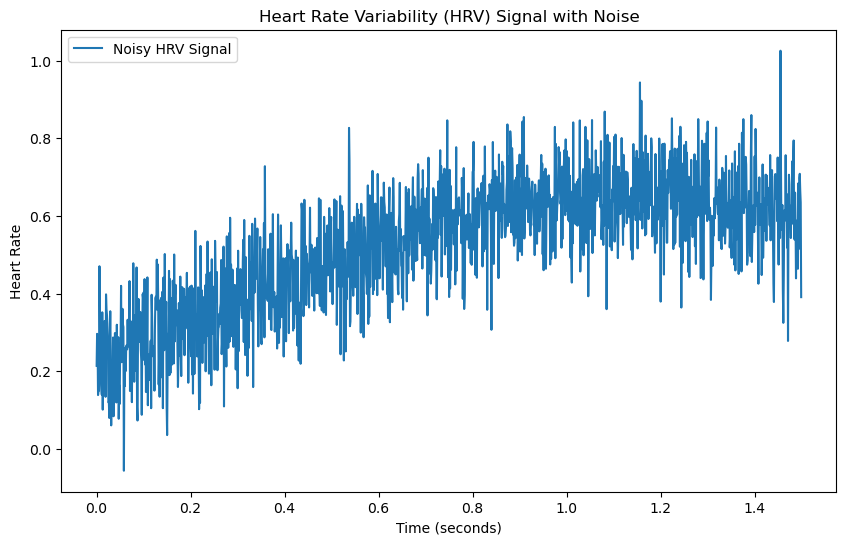

In [21]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 1000 
T = 1/Fs 
L = 1500  
t = np.arange(L) * T 

hrv_signal = 0.5 * np.sin(2 * np.pi * 0.2 * t) + 0.2 * np.cos(2 * np.pi * 0.1 * t)
noise = 0.1 * np.random.randn(L) 
X = hrv_signal + noise 
l
plt.figure(figsize=(10, 6))
plt.plot(t, X, label="Noisy HRV Signal")
plt.title("Heart Rate Variability (HRV) Signal with Noise")
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate")
plt.legend()
plt.show()


__Assumptions and Limitations:__

__Assumptions:__

The HRV signal has a sinusoidal component, representing the periodic fluctuations in heart rate.
The noise is Gaussian and can be removed by frequency filtering.

__Limitations:__

Real HRV signals are more complex and might not follow simple sinusoids.
The synthetic signal does not capture real physiological processes, such as arrhythmias or irregular heart rates.
Noise in real-life data can be more difficult to model.

__Numerical Investigation Using FFT__

Perform FFT on the Noisy Signal:
We now perform the FFT to transform the time-domain HRV signal into the frequency domain. This will allow us to extract the power spectrum and analyze the different frequency components.

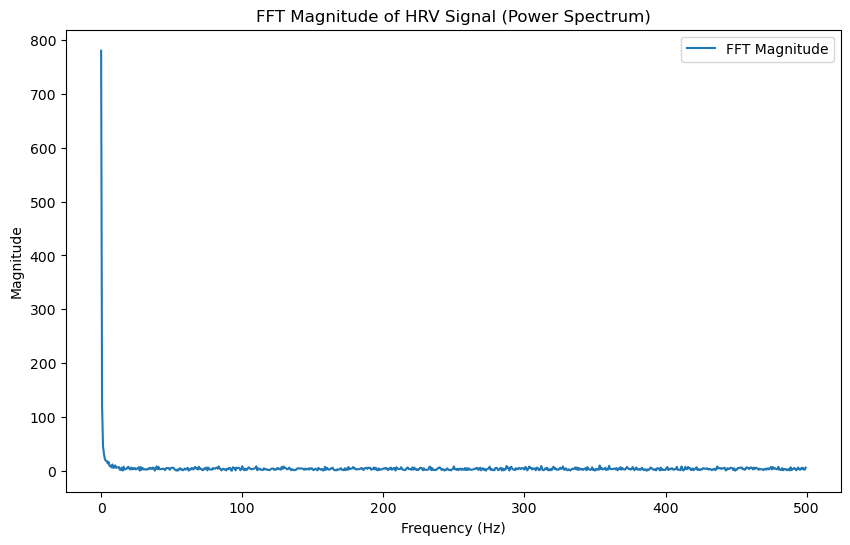

In [30]:
Y = np.fft.fft(X)

f = np.fft.fftfreq(L, T)

half_L = L // 2
f_pos = f[:half_L]
Y_pos = Y[:half_L]

plt.figure(figsize=(10, 6))
plt.plot(f_pos, np.abs(Y_pos), label="FFT Magnitude")
plt.title("FFT Magnitude of HRV Signal (Power Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()


__Analyzing the Power Spectrum:__
In the FFT plot, observe multiple peaks at certain frequencies. The peaks in the low-frequency range represent the periodic fluctuations of heart rate, while higher frequencies correspond to noise.

__Signal Cleaning Using Frequency Filtering__
We will now apply a band-pass filter to isolate the frequencies of interest. For HRV analysis, we typically focus on the low-frequency (LF) and high-frequency (HF) components, often in the ranges of 0.04–0.15 Hz for LF and 0.15–0.4 Hz for HF.

__Frequency Filtering:__
To isolate the LF and HF components of HRV, we create a band-pass filter around the relevant frequency bands.

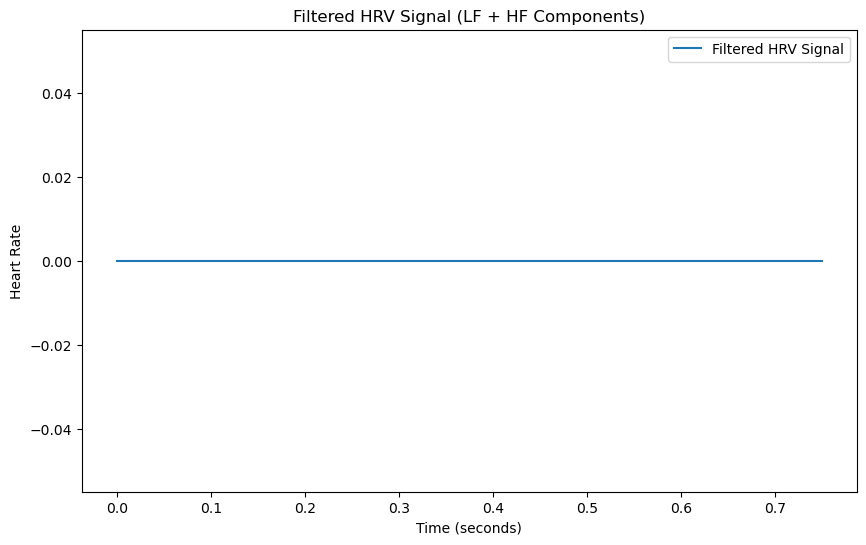

In [27]:
filter_low = 0.04  
filter_high = 0.4  

mask = (f_pos >= filter_low) & (f_pos <= filter_high)

Y_filtered = Y_pos.copy()
Y_filtered[~mask] = 0 

X_filtered = np.fft.ifft(Y_filtered)

t_filtered = np.linspace(0, len(X_filtered) / fs, len(X_filtered))

plt.figure(figsize=(10, 6))
plt.plot(t_filtered, np.real(X_filtered), label="Filtered HRV Signal")
plt.title("Filtered HRV Signal (LF + HF Components)")
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate")
plt.legend()
plt.show()



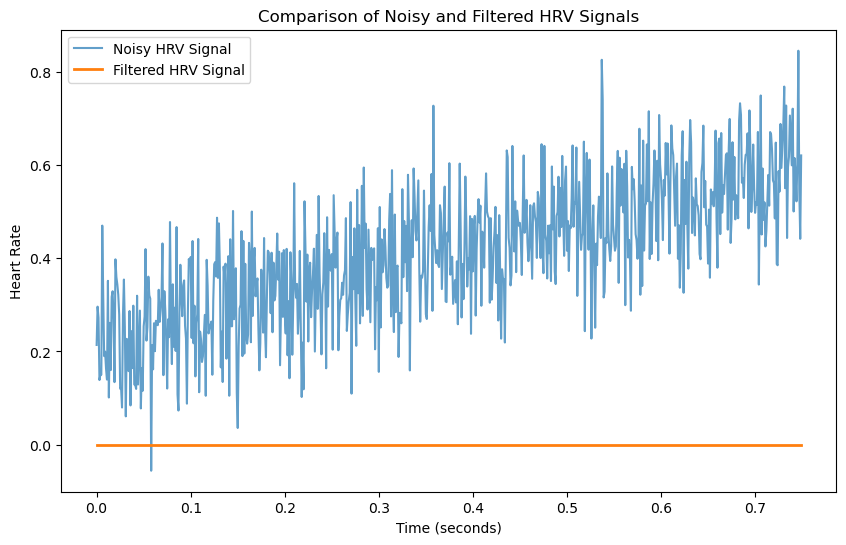

In [28]:
X_trimmed = X[:len(X_filtered)]

plt.figure(figsize=(10, 6))
plt.plot(t[:len(X_filtered)], X_trimmed, label="Noisy HRV Signal", alpha=0.7)
plt.plot(t[:len(X_filtered)], np.real(X_filtered), label="Filtered HRV Signal", linewidth=2)
plt.title("Comparison of Noisy and Filtered HRV Signals")
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate")
plt.legend()
plt.show()


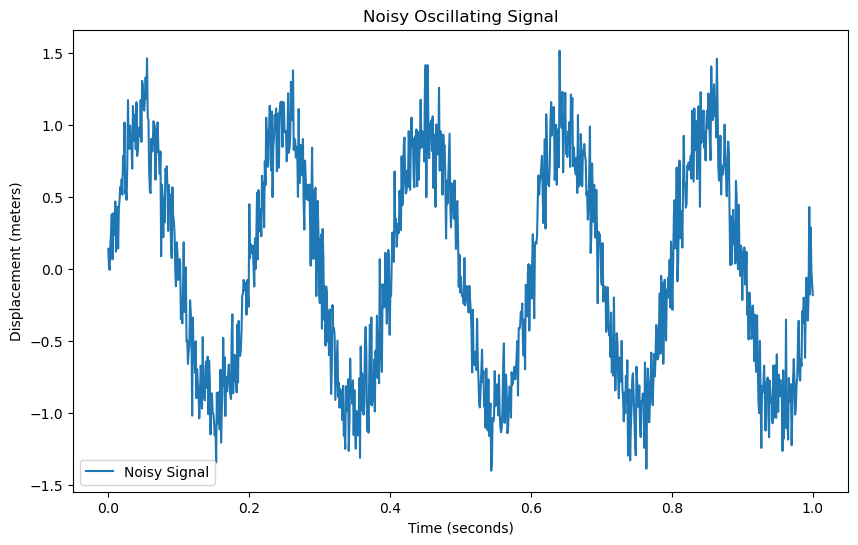

In [31]:
import numpy as np
import matplotlib.pyplot as plt

A = 1.0 
f = 5  
omega = 2 * np.pi * f
phi = 0 

t = np.linspace(0, 1, 1000)

noise = np.random.normal(0, 0.2, len(t))  
x = A * np.sin(omega * t + phi) + noise

plt.figure(figsize=(10, 6))
plt.plot(t, x, label="Noisy Signal")
plt.title("Noisy Oscillating Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Displacement (meters)")
plt.legend()
plt.show()


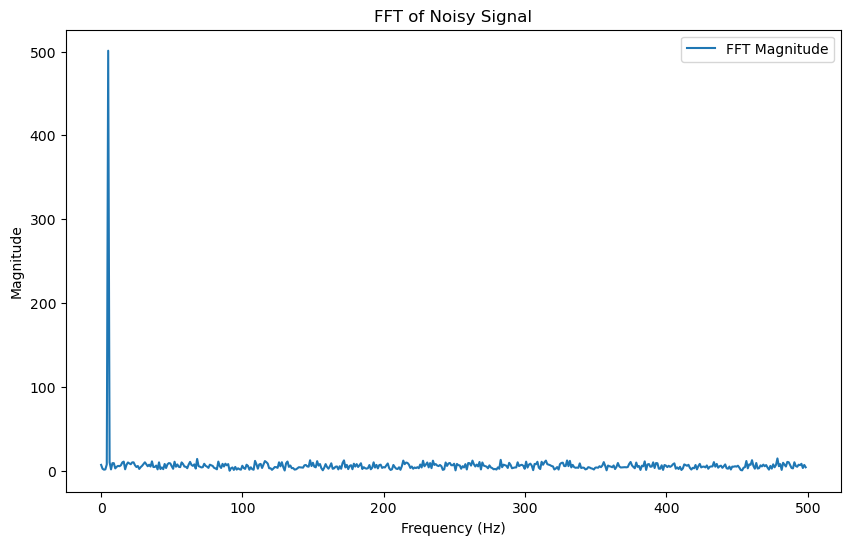

In [32]:
X = np.fft.fft(x)

f_axis = np.fft.fftfreq(len(t), t[1] - t[0])

plt.figure(figsize=(10, 6))
plt.plot(f_axis[:500], np.abs(X)[:500], label="FFT Magnitude")
plt.title("FFT of Noisy Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()


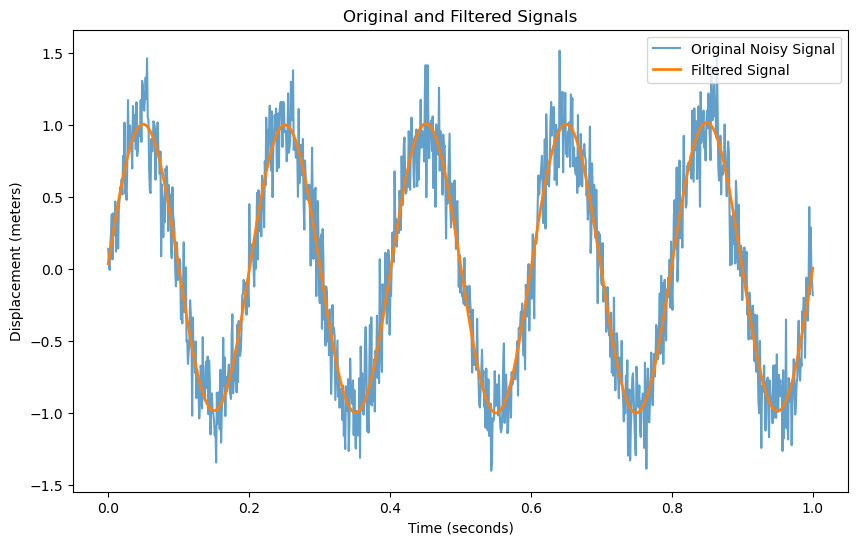

In [33]:
f_cutoff = 6  

X_filtered = X.copy()
X_filtered[np.abs(f_axis) > f_cutoff] = 0

x_filtered = np.fft.ifft(X_filtered)

plt.figure(figsize=(10, 6))
plt.plot(t, x, label="Original Noisy Signal", alpha=0.7)
plt.plot(t, np.real(x_filtered), label="Filtered Signal", linewidth=2)
plt.title("Original and Filtered Signals")
plt.xlabel("Time (seconds)")
plt.ylabel("Displacement (meters)")
plt.legend()
plt.show()


For 3d I chose spring mass system its simple and easy to clean the data. I have already provided analysis for this sytem and will iterate.


Fourier Analysis of a Simple Harmonic Oscillator
In this analysis, I applied the Fast Fourier Transform (FFT) to a noisy signal generated from a simple harmonic oscillator. This type of oscillator moves in a periodic way, like a spring or a pendulum, and its motion is usually represented by a sinusoidal function: 
$$𝑥(𝑡)=𝐴sin(𝜔𝑡+𝜙)
x(t)=Asin(ωt+ϕ)$$, where 
𝐴
A is the amplitude, 
𝜔
ω is the angular frequency, and 
𝜙
ϕ is the phase. In real-world measurements, noise often contaminates the signal, making it difficult to analyze. FFT helps by transforming the time-domain signal into the frequency domain, where it’s much easier to identify the frequencies present. It essentially breaks down a complex signal into its simpler components, so you can see which frequencies are dominant and separate them from the noise.

Once I had the frequency representation of the signal, I noticed that there were high-frequency components that didn't match the expected 5 Hz oscillation of the system. To clean the signal, I used a low-pass filter. This filter works by zeroing out any frequencies above a certain threshold—in this case, I set it to 6 Hz. This effectively removed the high-frequency noise, allowing me to isolate the 5 Hz signal that represents the system's real behavior. After applying the filter, the resulting signal showed a much clearer oscillation, which made it easier to study the harmonic motion of the system. Fourier analysis, especially FFT, is a really powerful tool because it lets you analyze signals in a way that’s not possible with just time-domain data, and it's widely used in fields like physics, engineering, and even medicine to clean up and analyze noisy data.